# 2 — The inverse problem, and why it needs a prior

*Series: **Bayesian fluorescence decays**, notebook 2 of 8. Builds §4 of
`THEORY.md`.*

**What this notebook establishes.** That inverting a decay for a distance
distribution is ill posed *even when everything else is known exactly*; how
badly; and what a roughness prior is for.

---

## The problem, written down

Notebook 1 ended on the fact that the expected counts are linear in the
distance distribution. Collect the eight histograms into one vector
$\boldsymbol\lambda$ and the distribution into $u_j = (1-x_{D0})p_j$ on the
$n_R$ grid points. Then

$$
\boldsymbol\lambda = \mathbf{X}\,u + \text{(donor-only, scatter, background)},
\qquad
\mathbf{X}_{\cdot j} = \text{the expected counts of one molecule at } r_j .
$$

So the question "what is $p(R)$" is a **linear inverse problem with Poisson
noise**. The Fisher information for $u$ is

$$
\mathcal{I} = \mathbf{X}^{\!\top} \operatorname{diag}(1/\boldsymbol\lambda)\, \mathbf{X},
$$

and how invertible *that* is decides everything. Below it is computed, not
argued about.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt
import bd

S = bd.default_settings(); S['threads'] = 4
model = bd.build_model(S)
L, Ep, rel = model['L'], model['Ep'], model['rel']
keys = model['keys']
wid = np.asarray(Ep['wid']); tc = np.asarray(Ep['tc'])

#: a truth with two populations, and one Poisson realisation of the eight histograms
p_true = bd.gaussian_truth(model, [0.85, 1.15], [0.55, 0.45], 0.06)
X_D0 = 0.2
y, lam_true, vals = bd.simulate_ensemble(model, S, p_true, x_d0=X_D0, photons=3e5, seed=3)
data_keys = [k for k in keys if k[0] != 'A0']
print('counts per histogram:')
for k in data_keys:
    print(f'  {k[0]} {k[1]}: {float(y[k].sum()):>9.0f}')

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
counts per histogram:
  D0 gv_vv:    309032
  D0 gh_vh:    217531
  D0 rv_vv:     16119
  D0 rh_vh:     11524
  DA gv_vv:    313685
  DA gh_vh:    205407
  DA rv_vv:    504268
  DA rh_vh:    403679


## The design matrix, one molecule at a time

Because the model is linear in the distribution, the column of $\mathbf{X}$
for grid point $j$ is literally the expected histogram of a single molecule at
that distance. Building $\mathbf{X}$ is therefore not an approximation of the
model — it *is* the model, reorganised.

To make the problem as easy as it can possibly be, everything else is held at
its true value: the response, the lifetime spectra, the anisotropies, the
crosstalks, the scale, the scatter and the background. Whatever difficulty
survives that is intrinsic.

In [2]:
import torch

def design_matrix(model, vals):
    #: columns: the expected counts, over all eight histograms, of one
    #: molecule at each grid point, every nuisance at its true value
    B = {}
    for k in keys:
        d = L.parse_channel(k)[1]
        if d not in B:
            #: bd.P.fine_response handles the alias: 'r2v' is the detector 'rv'
            #: seen from the red pulse, so its response is the same one displaced
            B[d] = L.basis_from_irf(Ep, bd.P.fine_response(model, d, vals), rebin=True)
    pairs = {('DA', f'{d}_{k2}'): ('A0', f'{L.PIE_PARTNER[d]}_{k2}')
             for d, k2 in (('gv','vv'),('gh','vh'),('rv','vv'),('rh','vh'))}
    cols = []
    v = dict(vals); v['x_d0'] = L.tt(0.0)                 # the column is a FRET molecule
    for j in range(len(rel)):
        e = np.zeros(len(rel)); e[j] = 1.0
        a = L.physics_amplitudes(Ep, v, Ep['cD'], L.tt(e), keys)
        col = []
        for k in data_keys:
            s = float(v[f'log_scale_{k[0]}'].exp())
            x = s * (B[L.parse_channel(k)[1]] @ a[k]).numpy()
            if k in pairs:
                kp = pairs[k]
                sp = float(v[f'log_scale_{kp[0]}'].exp())
                x = x + sp * (B[L.parse_channel(kp)[1]] @ a[kp]).numpy()
            col.append(x)
        cols.append(np.concatenate(col))
    return np.array(cols).T

Xd = design_matrix(model, vals)
lam_vec = np.concatenate([np.asarray(lam_true[k]) for k in data_keys])
y_vec = np.concatenate([np.asarray(y[k]) for k in data_keys])
print('design matrix', Xd.shape, '(bins x grid points)')

design matrix (1808, 128) (bins x grid points)


## How many directions are actually measured

Whiten by the Poisson noise, $\tilde{\mathbf X} = \operatorname{diag}(\lambda^{-1/2})\mathbf X$,
and look at its singular values. Each one says how many standard deviations of
data a unit of that direction of $u$ moves. A direction with a singular value
below 1 cannot be seen at all at this photon count.

This is the whole story of the field in one plot.

128 grid points, 15 directions above one standard deviation, condition number 1.20e+17
the 20th direction is 61789 times weaker than the first


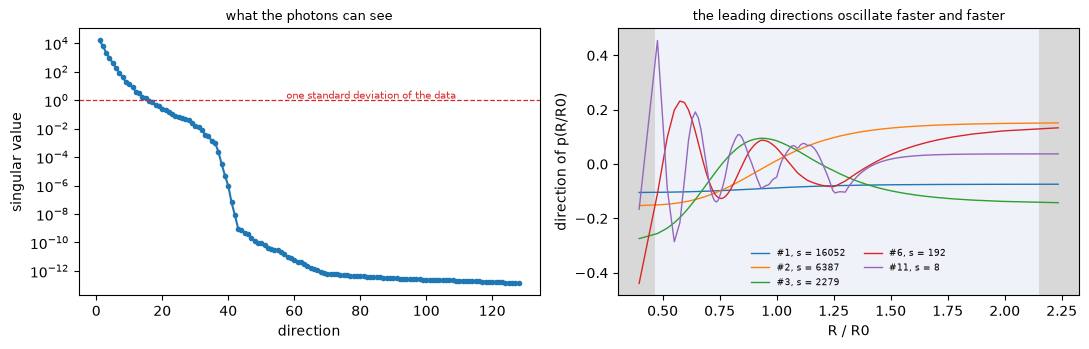

In [3]:
Xw = Xd / np.sqrt(np.maximum(lam_vec, 1e-12))[:, None]
sv = np.linalg.svd(Xw, compute_uv=False)
U, s, Vt = np.linalg.svd(Xw, full_matrices=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].semilogy(np.arange(1, len(sv) + 1), sv, 'C0o-', ms=3)
ax[0].axhline(1.0, color='C3', lw=0.9, ls='--')
ax[0].text(len(sv) * 0.45, 1.3, 'one standard deviation of the data', color='C3', fontsize=7)
ax[0].set_xlabel('direction'); ax[0].set_ylabel('singular value')
ax[0].set_title('what the photons can see', fontsize=9)
for i, c in zip((0, 1, 2, 5, 10), ('C0','C1','C2','C3','C4')):
    ax[1].plot(rel, Vt[i], c, lw=1.0, label=f'#{i+1}, s = {sv[i]:.0f}')
ax[1].set_xlabel('R / R0'); ax[1].set_ylabel('direction of p(R/R0)')
ax[1].legend(fontsize=6.5, frameon=False, ncol=2); L.shade_window(ax[1], 0.01, label=False)
ax[1].set_title('the leading directions oscillate faster and faster', fontsize=9)
fig.tight_layout()
n_seen = int((sv > 1).sum())
print(f'{len(sv)} grid points, {n_seen} directions above one standard deviation, '
      f'condition number {sv[0]/sv[-1]:.2e}')
print(f'the 20th direction is {sv[0]/sv[19]:.0f} times weaker than the first')

The spectrum falls off a cliff. Of 128 grid points, only a
few tens of directions move the data by more than the noise, and the ones that
do are the smooth ones — the leading right singular vectors are slowly varying
in $R/R_0$, and they oscillate faster the deeper one goes. **The data measure
a smooth function of distance and are blind to the rest.**

That is not a defect of the estimator. It is the physics of §2.3 of
`THEORY.md`: $E(r)=1/(1+r^6)$ is a smooth, monotone, saturating map, so two
distributions that differ by a fast wiggle produce the same decay.

## What happens with no prior at all

Solve the whitened least-squares problem for $u \ge 0$ and nothing else — the
maximum-likelihood answer in the Gaussian approximation, with every nuisance
at its true value. This is the best case, and it is unusable.

 seed  non-zero   mean R/R0    width
    3         6       0.970    0.151


    4         7       0.972    0.161
    5        10       0.970    0.160
truth       128       0.969    0.150


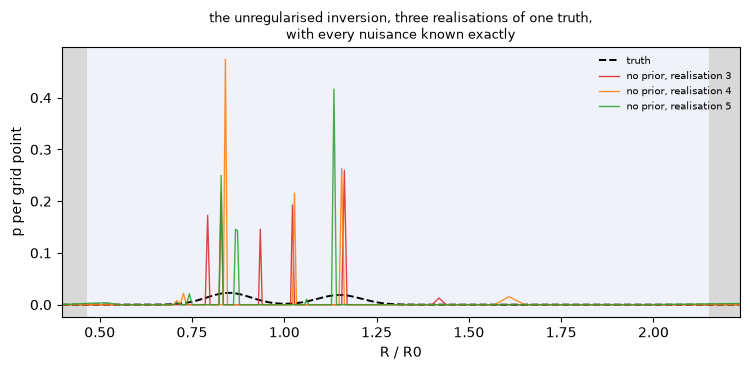

In [4]:
from scipy.optimize import nnls
A = Xd / np.sqrt(np.maximum(lam_vec, 1e-12))[:, None]
not_fret = lam_vec - Xd @ ((1 - X_D0) * p_true)          # donor-only, scatter, background
fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.plot(rel, p_true, 'k--', lw=1.4, label='truth')
print(f"{'seed':>5}{'non-zero':>10}{'mean R/R0':>12}{'width':>9}")
for seed, c in zip((3, 4, 5), ('C3', 'C1', 'C2')):
    y_s, _, _ = bd.simulate_ensemble(model, S, p_true, x_d0=X_D0, photons=3e5, seed=seed)
    b = (np.concatenate([np.asarray(y_s[k]) for k in data_keys]) - not_fret) / np.sqrt(np.maximum(lam_vec, 1e-12))
    u_ml, _ = nnls(A, b)
    p_ml = u_ml / max(u_ml.sum(), 1e-300)
    ax.plot(rel, p_ml, c, lw=1.0, alpha=0.85, label=f'no prior, realisation {seed}')
    m_ = float((p_ml * rel).sum())
    print(f'{seed:>5}{int((u_ml > 1e-9*u_ml.max()).sum()):>10}{m_:>12.3f}'
          f'{float(np.sqrt((p_ml*(rel-m_)**2).sum())):>9.3f}')
m_t = float((p_true * rel).sum())
print(f'{"truth":>5}{len(rel):>10}{m_t:>12.3f}{float(np.sqrt((p_true*(rel-m_t)**2).sum())):>9.3f}')
ax.set_xlabel('R / R0'); ax.set_ylabel('p per grid point'); ax.set_xlim(rel[0], rel[-1])
L.shade_window(ax, 0.01, label=False); ax.legend(fontsize=7, frameon=False)
ax.set_title('the unregularised inversion, three realisations of one truth,\nwith every nuisance known exactly', fontsize=9)
fig.tight_layout()

The answer is a handful of spikes out of 128 grid points, and each
Poisson realisation of the *same* truth puts them somewhere else. Its
*summaries* are not even bad — the mean and the width come out close, because
those are exactly the smooth directions the data do measure — but as a
distribution it is nonsense and it is unstable. Nothing about the data prefers
it to the smooth truth; the likelihood is flat along the directions the cliff above showed are
invisible, and the non-negativity constraint alone decides where the spikes
land.

## What a prior is for

The fix is not to fit less well. It is to say what was known before the
photons arrived: that a distance distribution of a molecular ensemble is a
smooth function, because it comes from thermal motion of a linker, not from a
comb.

A **P-spline** (Eilers & Marx 1996) says exactly that, and nothing more.
Represent the distribution on a B-spline basis and penalise the $m$-th
differences of the coefficients:

$$
p(r_j) = \operatorname{softmax}(\Phi c)_j,
\qquad
\pi(c\mid\lambda) \propto \lambda^{\operatorname{rank}(\mathbf{D}_m\Phi)/2}
\exp\!\Big(-\tfrac{\lambda}{2}\|\mathbf{D}_m c\|^2\Big).
$$

Three choices are hidden in that line, and each was made deliberately.

**Softmax, not $p$ itself.** Positivity and normalisation then hold by
construction rather than by constraint, and the fit never has to be told that
a probability cannot be negative.

**The penalty is on $\log p$.** In log space the penalty is scale free: a
population of a given relative width costs the same wherever it sits. Penalise
$p$ or $\sqrt{p}$ instead and a peak becomes cheaper where the distribution is
small, which biases the answer towards structure in the tails. Both
alternatives were tried in this project and withdrawn.

**The order $m$ is a statement about the null hypothesis**, because the null
space of $\mathbf{D}_m$ is unpenalised however large $\lambda$ gets. With
$m=2$ the free functions are linear in $\log p$, so infinite smoothing gives
$p(r)\propto e^{\beta r}$ — an exponential, not a flat line. With $m=3$ they
are quadratic in $\log p$, that is, **one Gaussian population is free at any
$\lambda$**. Notebook 3 shows both, and shows the shoulder that the $m=2$ null
hypothesis puts at the edge of the grid.

order 2: penalty rank 23, null space dimension 2
order 3: penalty rank 22, null space dimension 3


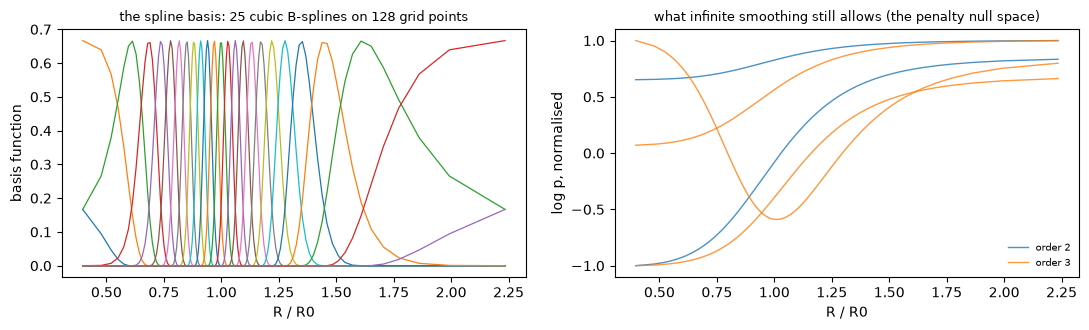

In [5]:
Phi = np.asarray(model['spl'])
def diff_matrix(n, m):
    D = np.eye(n)
    for _ in range(m):
        D = np.diff(D, axis=0)
    return D

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for j in range(Phi.shape[1]):
    ax[0].plot(rel, Phi[:, j], lw=0.9)
ax[0].set_xlabel('R / R0'); ax[0].set_ylabel('basis function')
ax[0].set_title(f'the spline basis: {Phi.shape[1]} cubic B-splines on {Phi.shape[0]} grid points', fontsize=9)
for m, c in ((2, 'C0'), (3, 'C1')):
    D = diff_matrix(Phi.shape[1], m)
    null = np.linalg.svd(D)[2][D.shape[0]:]
    for i, v in enumerate(null):
        ax[1].plot(rel, Phi @ v / np.abs(Phi @ v).max(), c, lw=1.0, alpha=0.8,
                   label=f'order {m}' if i == 0 else None)
ax[1].set_xlabel('R / R0'); ax[1].set_ylabel('log p, normalised')
ax[1].set_title('what infinite smoothing still allows (the penalty null space)', fontsize=9)
ax[1].legend(fontsize=7, frameon=False)
fig.tight_layout()
for m in (2, 3):
    D = diff_matrix(Phi.shape[1], m)
    print(f'order {m}: penalty rank {np.linalg.matrix_rank(D @ np.eye(Phi.shape[1]))}, '
          f'null space dimension {Phi.shape[1] - np.linalg.matrix_rank(D)}')

## The penalty at work, and the choice it forces

Solve the same inversion with a second-difference penalty of weight $\lambda$,
for a range of $\lambda$. This is the penalised least-squares version — the
real model is Poisson and works in $\log p$, but the picture is the same and
the point is what $\lambda$ does.

Too small and the spikes come back. Too large and the two populations merge
into one hump. **Somewhere in between is right, and nothing in this plot says
where.** That is the question notebook 3 is about, and the answer is not to
pick the best-looking one.

  lambda 1e 0: effective parameters   19.0 of 128
  lambda 1e 2: effective parameters   13.5 of 128
  lambda 1e 4: effective parameters   10.2 of 128
  lambda 1e 6: effective parameters    7.4 of 128
  lambda 1e 8: effective parameters    5.5 of 128


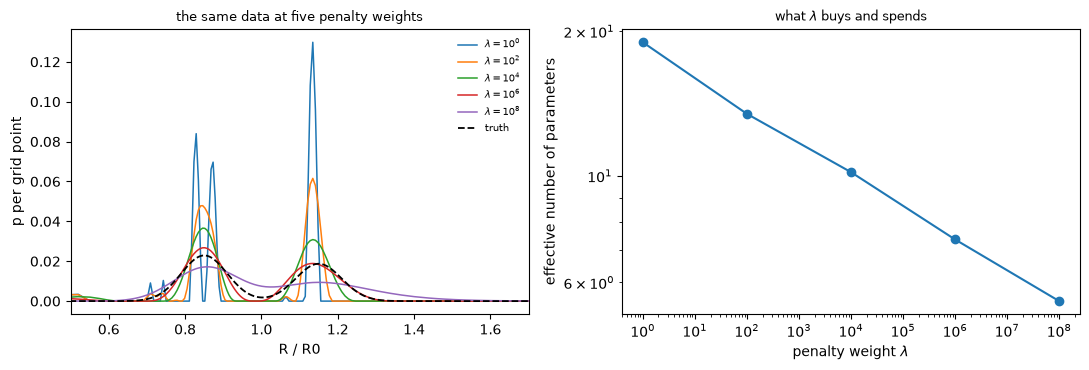

In [6]:
D2 = diff_matrix(len(rel), 2)
lams = [1e0, 1e2, 1e4, 1e6, 1e8]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
edf = []
for lam_, c in zip(lams, ('C0', 'C1', 'C2', 'C3', 'C4')):
    M = np.vstack([A, np.sqrt(lam_) * D2])
    rhs = np.concatenate([b, np.zeros(D2.shape[0])])
    u, _ = nnls(M, rhs)
    p_ = u / max(u.sum(), 1e-300)
    ax[0].plot(rel, p_, c, lw=1.1, label=f'$\\lambda = 10^{{{int(np.log10(lam_))}}}$')
    H = A.T @ A + lam_ * (D2.T @ D2)
    edf.append(float(np.trace(np.linalg.solve(H, A.T @ A))))
ax[0].plot(rel, p_true, 'k--', lw=1.3, label='truth')
ax[0].set_xlabel('R / R0'); ax[0].set_ylabel('p per grid point'); ax[0].set_xlim(0.5, 1.7)
ax[0].legend(fontsize=7, frameon=False); ax[0].set_title('the same data at five penalty weights', fontsize=9)
ax[1].loglog(lams, edf, 'C0o-')
ax[1].set_xlabel('penalty weight $\\lambda$'); ax[1].set_ylabel('effective number of parameters')
ax[1].set_title('what $\\lambda$ buys and spends', fontsize=9)
fig.tight_layout()
for lam_, e in zip(lams, edf):
    print(f'  lambda 1e{int(np.log10(lam_)):>2d}: effective parameters {e:6.1f} of {len(rel)}')

## What comes next

The prior turned an unusable inversion into a family of answers indexed by one
number. That number is now the whole problem: it is not a nuisance to be
picked by eye, and — as notebook 3 shows by trying it — it is also not
something that can be estimated jointly with everything else.

**Established here.** The design matrix and the Fisher information for the
distribution (THEORY §2.4, §5.4); the singular spectrum, showing that only a
few tens of smooth directions are measured; the unregularised inversion and
its spikes; the P-spline prior with its three deliberate choices — softmax,
$\log p$, and the order — and the null space each order leaves free (§4).